# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.3302,  0.4361,  0.6819,  0.3046, -0.0654, -0.8460, -0.6136, -1.0945,
         -0.2072, -0.0469]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4076, Train Acc: 0.8836, Val Loss: 0.3183, Val Acc: 0.9108
Epoch [2/5], Train Loss: 0.3123, Train Acc: 0.9117, Val Loss: 0.3042, Val Acc: 0.9139
Epoch [3/5], Train Loss: 0.2976, Train Acc: 0.9155, Val Loss: 0.2982, Val Acc: 0.9167
Epoch [4/5], Train Loss: 0.2874, Train Acc: 0.9187, Val Loss: 0.2904, Val Acc: 0.9211
Epoch [5/5], Train Loss: 0.2812, Train Acc: 0.9210, Val Loss: 0.2897, Val Acc: 0.9196


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2812
Última acurácia de treinamento: 0.9210
Última perda de validação: 0.2897
Última acurácia de validação: 0.9196


### Visualizando a evolução da perda e acurácia

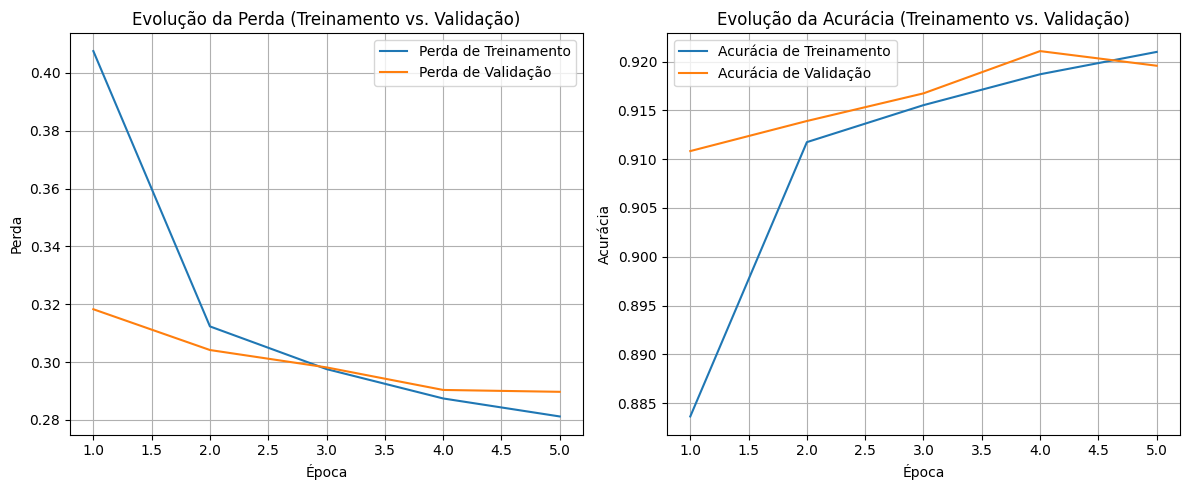

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
2. Em uma época, quantos mini-batches existem?
3. Qual é a definição de época?

1. Qual o tamanho do mini-batch

O tamanho do mini-batch é 100, como definido em `batch_size = 100`

2. Em uma época, quantos mini-batches existem?

A quantidade de mini-batches depende da quantidade de elementos em um dataset. Supondo um dataset com 1000 elementos e usando um batch size de 100, cada época teria 1000/100 = 10 minibatches. Nesse caso específico, no dataset de validação temos 48000 elementos, de forma que temos 48000/100 = batches por época

3. Qual a definição de época?

Época é a passada por todos os dados do dataset de treinamento do modelo, realizando a atualização dos pesos do modelo.

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

In [ ]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        print(f'Época: {epoch+1}/{n_epochs}, batch: {i}')

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    #print(f'Epoch [{epoch+1}/{n_epochs}], ' \
    #      f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
    #      f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Modificando os valores de batch size e realizando novos treinamentos

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 240
Número de minibatches de validação: 60

Dimensões dos dados de um minibatch de treinamento: torch.Size([200, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>
Número de minibatches de treinamento: 240
Número de minibatches de validação: 60
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000
torch.Size([1, 784])
Epoch [1/5], Train Loss: 0.4645, Train Acc: 0.8706, Val Loss: 0.3412, Val Acc: 0.9036
Epoch [2/5], Train Loss: 0.3312, Train Acc: 0.9079, Val Loss: 0.3122, Val Acc: 0.9119
Epoch [3/5], Train Loss: 0.3101, Train Acc: 0.9127, Val Loss: 0.2990, Val Acc: 0.9169
Epoch [4/5], Train Loss: 0.2992, Train Acc: 0.9158, Val Loss: 0.2898, Val Acc: 0.918

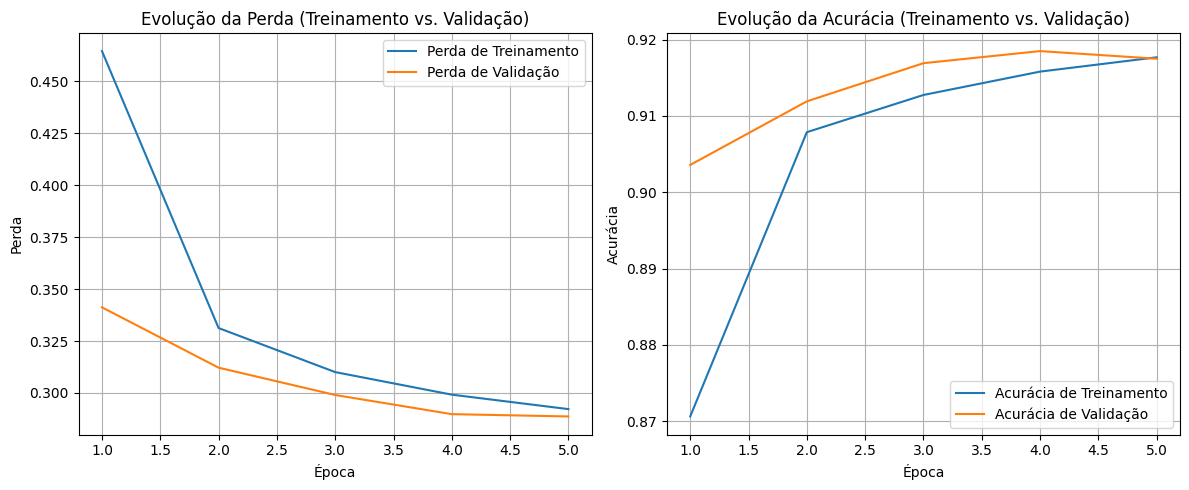

In [13]:
batch_size = 200

dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

model = torch.nn.Linear(28*28, 10)

x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)

n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 80
Número de minibatches de validação: 20

Dimensões dos dados de um minibatch de treinamento: torch.Size([600, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>
Número de minibatches de treinamento: 80
Número de minibatches de validação: 20
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000
torch.Size([1, 784])
Epoch [1/5], Train Loss: 0.6130, Train Acc: 0.8387, Val Loss: 0.4173, Val Acc: 0.8864
Epoch [2/5], Train Loss: 0.3850, Train Acc: 0.8951, Val Loss: 0.3669, Val Acc: 0.8962
Epoch [3/5], Train Loss: 0.3508, Train Acc: 0.9026, Val Loss: 0.3440, Val Acc: 0.9028
Epoch [4/5], Train Loss: 0.3328, Train Acc: 0.9081, Val Loss: 0.3308, Val Acc: 0.9073


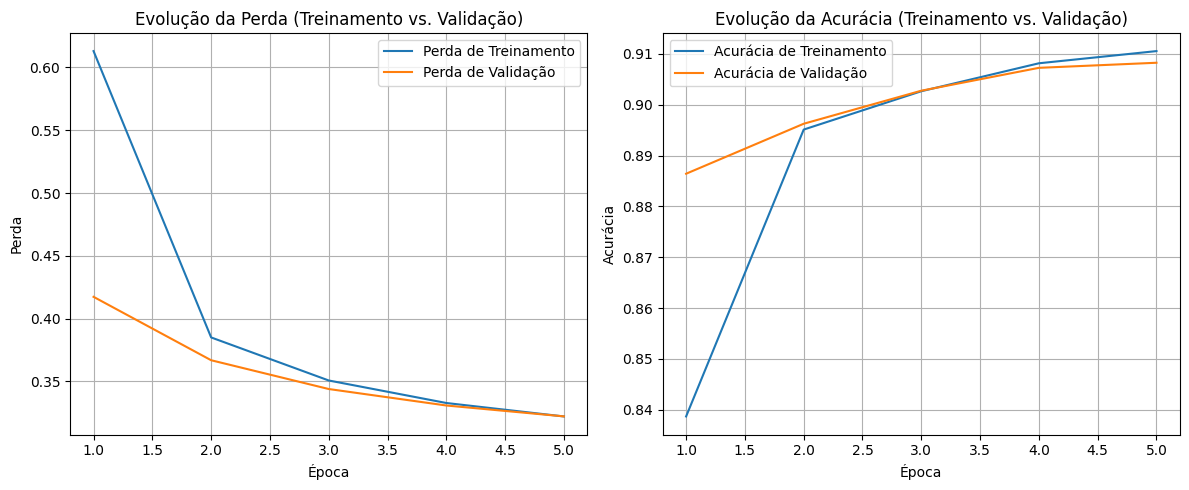

In [12]:
batch_size = 600

dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

model = torch.nn.Linear(28*28, 10)

x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)

n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 40
Número de minibatches de validação: 10

Dimensões dos dados de um minibatch de treinamento: torch.Size([1200, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>
Número de minibatches de treinamento: 40
Número de minibatches de validação: 10
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000
torch.Size([1, 784])
Epoch [1/5], Train Loss: 0.7628, Train Acc: 0.8166, Val Loss: 0.4921, Val Acc: 0.8750
Epoch [2/5], Train Loss: 0.4455, Train Acc: 0.8829, Val Loss: 0.4157, Val Acc: 0.8892
Epoch [3/5], Train Loss: 0.3956, Train Acc: 0.8929, Val Loss: 0.3843, Val Acc: 0.8968
Epoch [4/5], Train Loss: 0.3705, Train Acc: 0.8975, Val Loss: 0.3661, Val Acc: 0.9023

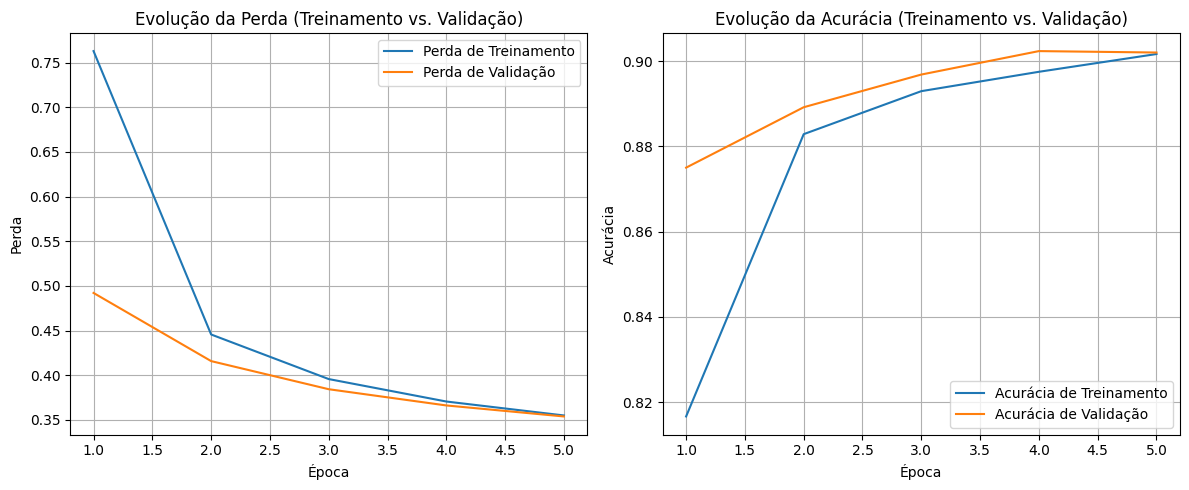

In [14]:
batch_size = 1200

dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

model = torch.nn.Linear(28*28, 10)

x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)

n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 20
Número de minibatches de validação: 5

Dimensões dos dados de um minibatch de treinamento: torch.Size([2400, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>
Número de minibatches de treinamento: 20
Número de minibatches de validação: 5
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000
torch.Size([1, 784])
Epoch [1/5], Train Loss: 0.9867, Train Acc: 0.7671, Val Loss: 0.6042, Val Acc: 0.8563
Epoch [2/5], Train Loss: 0.5385, Train Acc: 0.8683, Val Loss: 0.4870, Val Acc: 0.8735
Epoch [3/5], Train Loss: 0.4634, Train Acc: 0.8804, Val Loss: 0.4411, Val Acc: 0.8811
Epoch [4/5], Train Loss: 0.4262, Train Acc: 0.8875, Val Loss: 0.4142, Val Acc: 0.8872
E

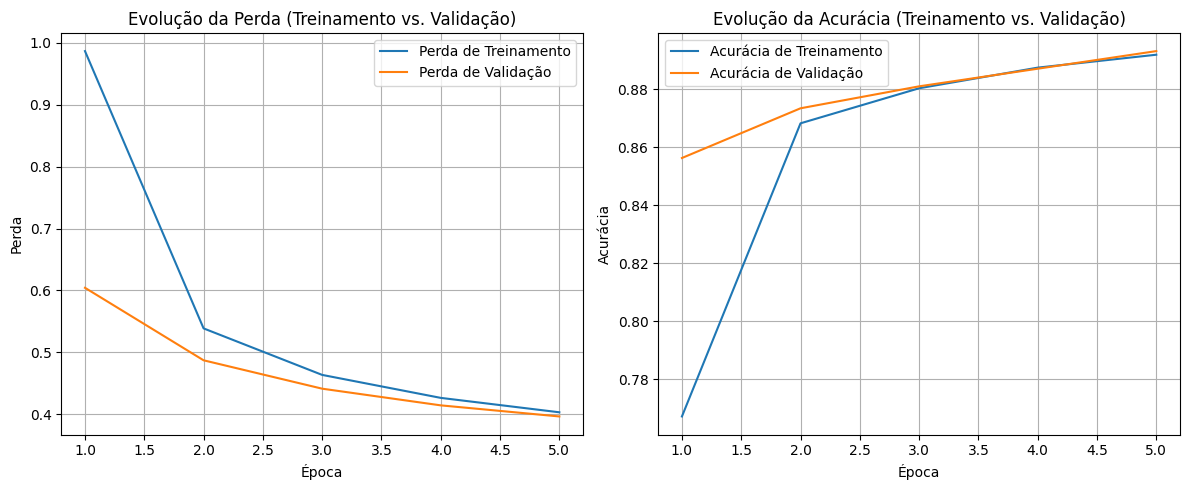

In [15]:
batch_size = 2400

dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

model = torch.nn.Linear(28*28, 10)

x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)

n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Há uma tendência de ligeira queda no valor de acurácia para o dataset de validação e treinamento com o aumento dos valores para os mini-batches. O que pode ser entendido como esperado, já que o modelo atualiza os pesos olhando para quantidades maiores de dados do dataset de treinamento, gerando atualizações de pesos menos específicas.

## Conclusões sobre os experimentos deste notebook
